|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Understand and design CNNs<h1>|
|<h2>Lecture:</h2>|<h1><b>The EMNIST dataset (letter recognition)<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import os
import time
import copy
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary

# for importing data
import torchvision

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# use GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Import and inspect the data

In [3]:
# download the dataset
cdata = torchvision.datasets.EMNIST(root='../sample_data/emnist',
                                    split='letters',download=True)

# more info: https://www.nist.gov/itl/products-and-services/emnist-dataset

In [4]:
# inspect the data

# the categories (but how many letters??)
print(cdata.classes)
print(str(len(cdata.classes)) + ' classes')

print('\nData size:')
print(cdata.data.shape)

# transform to 4D tensor for conv layers (and transform from int8 to float)
images = cdata.data.view([124800,1,28,28]).float()
print('\nTensor data:')
print(images.shape)


['N/A', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
27 classes

Data size:
torch.Size([124800, 28, 28])

Tensor data:
torch.Size([124800, 1, 28, 28])


In [5]:
# brief aside: class 'N/A' doesn't exist in the data.
print( torch.sum(cdata.targets==0) )

# However, it causes problems in one-hot encoding...
torch.unique(cdata.targets)

tensor(0)


tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26])

In [6]:
cdata.class_to_idx

{'N/A': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [7]:
# so therefore we'll eliminate it and subtract 1 from the original

# remove the first class category
letterCategories = cdata.classes[1:]

# relabel labels to start at 0
labels = copy.deepcopy(cdata.targets)-1
print(labels.shape)

###
print( torch.sum(labels==0) )
torch.unique(labels)

torch.Size([124800])
tensor(4800)


tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25])

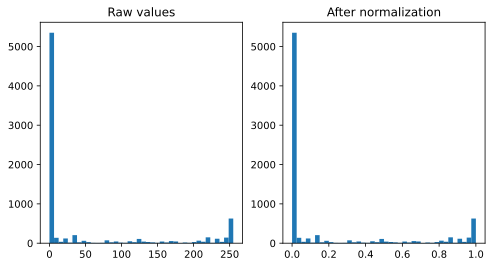

In [8]:
# next issue: do we need to normalize the images?
fig, axs = plt.subplots(1,2, figsize=(8,4))
axs[0].hist(torch.squeeze(images[:10,:,:,:]).to(torch.float32).flatten().detach().numpy(), 40)
axs[0].set_title('Raw values')

# yarp.
images = (images - torch.min(images)) / (torch.max(images) - torch.min(images))

axs[1].hist(torch.squeeze(images[:10,:,:,:]).to(torch.float32).flatten().detach().numpy(), 40)
axs[1].set_title('After normalization')

plt.show()

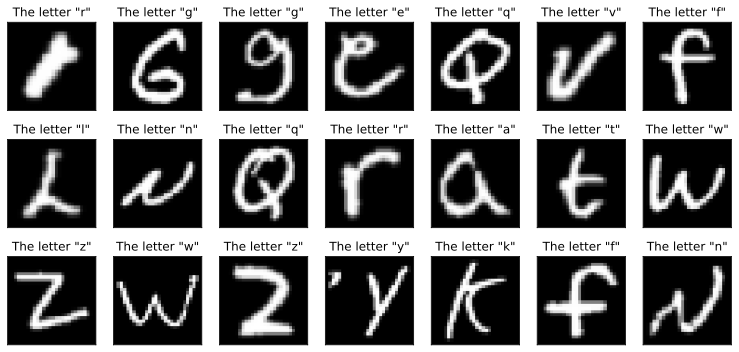

In [9]:
# visualize some images
fig,axs = plt.subplots(3,7,figsize=(13,6))

for i,ax in enumerate(axs.flatten()):

  # pick a random pic
  whichpic = np.random.randint(images.shape[0])

  # extract the image and its target letter
  I = np.squeeze( images[whichpic,:,:] )
  letter = letterCategories[labels[whichpic]]

  # visualize
  ax.imshow(I.T,cmap='gray')
  ax.set_title('The letter "%s"'%letter)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Create train/test groups using DataLoader

In [10]:
# Step 2: use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(images, labels, test_size=.1)

# Step 3: convert into PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# Step 4: translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [11]:
# check size (should be images X channels X width X height
print( train_loader.dataset.tensors[0].shape )
print( train_loader.dataset.tensors[1].shape )

torch.Size([112320, 1, 28, 28])
torch.Size([112320])


# Create the DL model

In [12]:
# create a class for the model
def makeTheNet(conv_layer_size:tuple=(6,6), printtoggle:bool=False):

  class emnistnet(nn.Module):
    def __init__(self,conv_layer_size:tuple=(6,6), printtoggle:bool=False):
      super().__init__()
      
      self.inSize = 28
      self.pool2d_kernel_sz = 2
      self.conv_layer_kernel_size = (3,3) # conv1, conv2, ...

      # print toggle
      self.print = printtoggle
      
      # For equation see: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
      CNNLayerOutSize = lambda inSize, p, kzs, s, psz: \
        int(np.ceil((inSize + 2*p - kzs)//s + 1)//psz)

      ### -------------- feature map layers -------------- ###
      # first convolution layer
      self.conv1  = nn.Conv2d(1,conv_layer_size[0],self.conv_layer_kernel_size[0],padding=1)
      self.bnorm1 = nn.BatchNorm2d(self.conv1.out_channels) # input the number of channels in this layer
      # output size: (28+2*1-3)/1 + 1 = 28/2 = 14 (/2 b/c maxpool)
      nOutCNNLayer1 =  CNNLayerOutSize(self.inSize, self.conv1.padding[0], self.conv1.kernel_size[0], self.conv1.stride[0], self.pool2d_kernel_sz)
      if self.print: print(f'nOutCNNLayer1: {nOutCNNLayer1}')

      # second convolution layer
      self.conv2  = nn.Conv2d(self.conv1.out_channels,conv_layer_size[1],self.conv_layer_kernel_size[1],padding=1)
      self.bnorm2 = nn.BatchNorm2d(self.conv2.out_channels) # input the number of channels in this layer
      # output size: (14+2*1-3)/1 + 1 = 14/2 = 7 (/2 b/c maxpool)
      nOutCNNLayer2 = CNNLayerOutSize(nOutCNNLayer1, self.conv2.padding[0], self.conv2.kernel_size[0], self.conv2.stride[0], self.pool2d_kernel_sz)
      if self.print: print(f'nOutCNNLayer2: {nOutCNNLayer2}')

      ### -------------- linear decision layers -------------- ###
      self.fc1 = nn.Linear(nOutCNNLayer2*nOutCNNLayer2*self.conv2.out_channels, 50)
      self.fc2 = nn.Linear(self.fc1.out_features,26)

    def forward(self,x):

      if self.print: print(f'Input: {list(x.shape)}')

      # first block: convolution -> maxpool -> batchnorm -> relu
      x = F.max_pool2d(self.conv1(x),2,self.pool2d_kernel_sz)
      x = F.leaky_relu(self.bnorm1(x))
      if self.print: print(f'First CPR block: {list(x.shape)}')

      # second block: convolution -> maxpool -> batchnorm -> relu
      x = F.max_pool2d(self.conv2(x),2,self.pool2d_kernel_sz)
      x = F.leaky_relu(self.bnorm2(x))
      if self.print: print(f'Second CPR block: {list(x.shape)}')

      # reshape for linear layer
      x = x.flatten(start_dim=1)
      if self.print: print(f'Vectorized: {list(x.shape)}')

      # linear layers
      x = F.leaky_relu(self.fc1(x))
      x = self.fc2(x)
      if self.print: print(f'Final output: {list(x.shape)}')

      return x

  # create the model instance
  net = emnistnet(conv_layer_size,printtoggle)

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

In [13]:
# test the model with one batch
net,lossfun,optimizer = makeTheNet(printtoggle=True)

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print('\nOutput size:')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,torch.squeeze(y))
print(' ')
print('Loss:')
print(loss)

nOutCNNLayer1: 14
nOutCNNLayer2: 7
Input: [32, 1, 28, 28]
First CPR block: [32, 6, 14, 14]
Second CPR block: [32, 6, 7, 7]
Vectorized: [32, 294]
Final output: [32, 26]

Output size:
torch.Size([32, 26])
 
Loss:
tensor(3.3120, grad_fn=<NllLossBackward0>)


In [14]:
net_summary,_,_ = makeTheNet()
summary(net_summary,(1,28,28), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]              60
       BatchNorm2d-2            [-1, 6, 14, 14]              12
            Conv2d-3            [-1, 6, 14, 14]             330
       BatchNorm2d-4              [-1, 6, 7, 7]              12
            Linear-5                   [-1, 50]          14,750
            Linear-6                   [-1, 26]           1,326
Total params: 16,490
Trainable params: 16,490
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 0.06
Estimated Total Size (MB): 0.12
----------------------------------------------------------------


# Create a function that trains the model

In [15]:
# a function that trains the model

def function2trainTheModel(conv_layer_size:tuple=(6,6), numepochs:int=10):

  # create a new model
  net,lossfun,optimizer = makeTheNet(conv_layer_size=conv_layer_size)

  # send the model to the GPU
  net.to(device)

  # initialize losses
  trainLoss = torch.zeros(numepochs)
  testLoss  = torch.zeros(numepochs)
  trainErr  = torch.zeros(numepochs)
  testErr   = torch.zeros(numepochs)


  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    net.train()
    batchLoss = []
    batchErr  = []
    for X,y in train_loader:

      # push data to GPU
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss and error from this batch
      batchLoss.append(loss.item())
      batchErr.append( torch.mean((torch.argmax(yHat,axis=1) != y).float()).item() )
    # end of batch loop...

    # and get average losses and error rates across the batches
    trainLoss[epochi] = np.mean(batchLoss)
    trainErr[epochi]  = 100*np.mean(batchErr)

    ### test performance
    net.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader

    # push data to GPU
    X = X.to(device)
    y = y.to(device)

    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      loss = lossfun(yHat,y)

    # get loss and error rate from the test batch
    testLoss[epochi] = loss.item()
    testErr[epochi]  = 100*torch.mean((torch.argmax(yHat,axis=1) != y).float()).item()

  # end epochs

  # function output
  return trainLoss,testLoss,trainErr,testErr,net

# Run the model and show the results!

In [16]:
# ~2 minutes with 10 epochs on GPU (8 mins on the CPU!)

units_per_layer = sorted([2, 5, 8])
numepochs = 5
trainLoss = {}
testLoss = {}
trainErr = {}
testErr = {}
trainTime = np.zeros((len(units_per_layer), len(units_per_layer)))
net = {}
for i, Ni in enumerate(units_per_layer):
    for j, Nj in enumerate(units_per_layer):
        start_time = time.time()
        trainLoss[(Ni,Nj)], testLoss[(Ni,Nj)], trainErr[(Ni,Nj)], testErr[(Ni,Nj)], net[(Ni,Nj)] = \
            function2trainTheModel(conv_layer_size=(Ni,Nj), numepochs=numepochs)
        trainTime[(i,j)] = time.time() - start_time
        # break
    # break

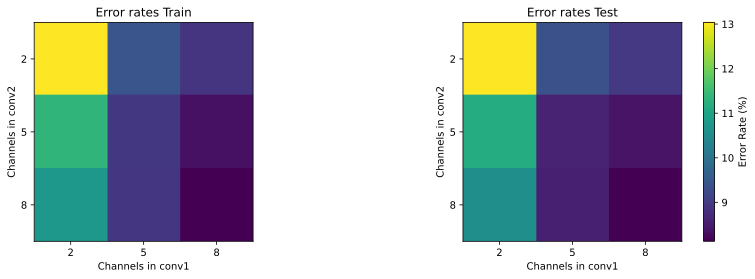

Training time (s):
[[54.78307557 50.65642047 53.67444921]
 [52.04837871 48.82876086 50.21156406]
 [51.05034256 52.62868333 49.40603805]]


In [20]:
# Show the results in a 3x3 matrix of final error rates from each test, and as a function of total filter kernels
finalTestErr = np.zeros((len(units_per_layer), len(units_per_layer)))
finalTrainErr = np.zeros((len(units_per_layer), len(units_per_layer)))
totalConvChannels = np.zeros((len(units_per_layer), len(units_per_layer)))
for i, u1 in enumerate(units_per_layer):
    for j, u2 in enumerate(units_per_layer):
        finalTestErr[i,j] = testErr[(u1,u2)][-1]
        finalTrainErr[i,j] = trainErr[(u1,u2)][-1]
        totalConvChannels[i,j] = u1 + u2
totalConvChannels = totalConvChannels.flatten()

fig,axs = plt.subplots(1,2,figsize=(12,4))

axs[0].imshow(finalTrainErr, vmin=np.min(finalTrainErr), vmax=np.max(finalTrainErr))
axs[0].set_title('Error rates Train')

axs[1].imshow(finalTestErr, vmin=np.min(finalTestErr), vmax=np.max(finalTestErr))
axs[1].set_title('Error rates Test')

for a in axs.flatten():
    a.set_xlabel('Channels in conv1')
    a.set_ylabel('Channels in conv2')
    a.set_xticks(np.arange(len(units_per_layer)))
    a.set_yticks(np.arange(len(units_per_layer)))
    a.set_xticklabels(units_per_layer)
    a.set_yticklabels(units_per_layer)
    
cbar = fig.colorbar(axs[1].images[0], ax=axs[1])
cbar.set_label('Error Rate (%)')

fig.tight_layout()
plt.show()

print('Training time (s):')
print(trainTime)

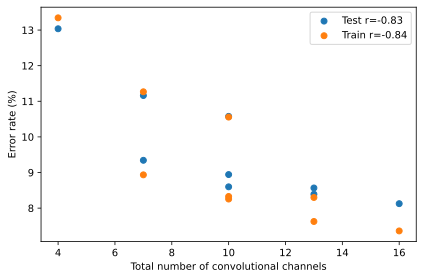

In [18]:
fig = plt.figure(figsize=(6,4))

finalTestErr_corr = np.corrcoef(finalTestErr.flatten(), totalConvChannels)[0,1]
finalTrainErr_corr = np.corrcoef(finalTrainErr.flatten(), totalConvChannels)[0,1]

plt.scatter(totalConvChannels, finalTestErr.flatten(), label=f'Test r={finalTestErr_corr:.2f}')
plt.scatter(totalConvChannels, finalTrainErr.flatten(), label=f'Train r={finalTrainErr_corr:.2f}')
plt.xlabel('Total number of convolutional channels')
plt.ylabel('Error rate (%)')
plt.legend()

fig.tight_layout()
plt.show()

# Additional explorations

In [19]:
# 1) The correlation between error rate and convolution channels looks pretty compelling. How far do you dare go?!?! Try
#    adding more channels. Does the error rate simply keep going down until it reaches zero? Or do you find a point of
#    "diminishing returns", meaning that adding more channels no longer improves performance.
# Answer: See L186_my. Adding more channels does improve performance,
# but there is a point of diminishing returns where the improvement becomes less significant.
#
# 2) It seems intuitive that models with more layers take longer to train. But if there's one thing you've learned about
#    deep learning, it's that intuition doesn't always get us very far. Thus: modify the code to track the training time
#    for each model. Store the results in a separate matrix, and make an image of those results. Do they look like what
#    you had expected?
#
# 3) Are net.train() and net.eval() necessary here? Why or why not?
# Answer: Yes, they are necessary, since batch normalization is used.
#